In [1]:
#import and read the US births dataset

import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("basketball_heights.csv")

In [2]:
df.head()

,region_1,region_2,region_3
0,1.834604,1.817755,1.833082
1,1.809238,1.713023,1.993077
2,1.643073,1.786917,1.910538
3,1.821316,1.802915,1.891940
4,1.819650,1.707106,1.758786


In [3]:
df.tail()

,region_1,region_2,region_3
15,NaN,1.639003,NaN
16,NaN,1.790037,NaN
17,NaN,1.711083,NaN
18,NaN,1.833889,NaN
19,NaN,1.656471,NaN


In [4]:
df.shape

(20, 3)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   region_1  10 non-null     float64
 1   region_2  20 non-null     float64
 2   region_3  15 non-null     float64
dtypes: float64(3)
memory usage: 612.0 bytes


In [6]:
df.describe()

,region_1,region_2,region_3
count,10.000000,20.000000,15.000000
mean,1.809549,1.742228,1.924604
std,0.086137,0.058774,0.112180
min,1.643073,1.639003,1.646696
25%,1.811841,1.707022,1.880071
50%,1.823583,1.733850,1.951662
75%,1.861862,1.787697,1.991472
max,1.915565,1.850859,2.075395


In [7]:
df.isnull().sum()

region_1    10
region_2     0
region_3     5
dtype: int64

In [8]:
df=df.dropna()

In [9]:
df.isnull().sum()

region_1    0
region_2    0
region_3    0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   region_1  10 non-null     float64
 1   region_2  10 non-null     float64
 2   region_3  10 non-null     float64
dtypes: float64(3)
memory usage: 320.0 bytes


In [11]:
df.duplicated().sum()

0

In [12]:
df.columns

Index(['region_1', 'region_2', 'region_3'], dtype='object')

In [13]:
df.mean()

region_1    1.809549
region_2    1.748213
region_3    1.893951
dtype: float64

In [14]:
df.median()

region_1    1.823583
region_2    1.749062
region_3    1.901239
dtype: float64

In [15]:
df.std()

region_1    0.086137
region_2    0.048171
region_3    0.123257
dtype: float64

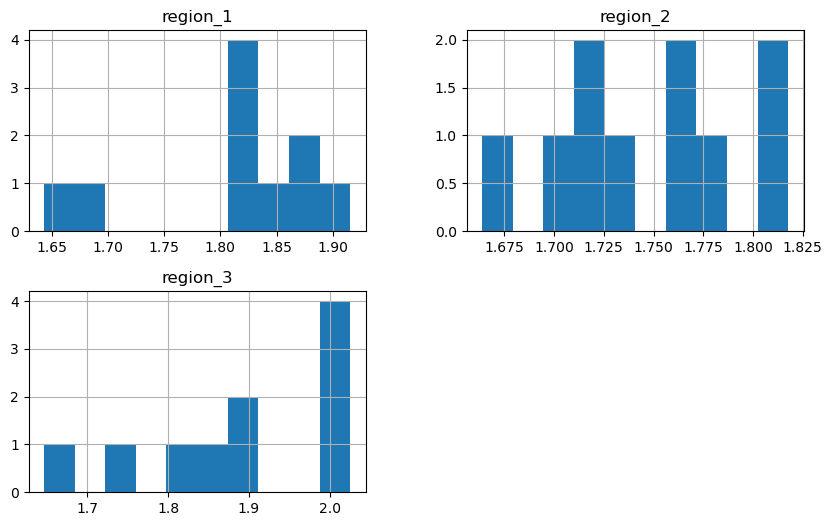

In [16]:
df[['region_1','region_2','region_3']].hist(figsize=(10,6))
plt.show()

The histograms show that the values in all three regions are distributed within a relatively narrow range, indicating consistency across regions. Region 3 appears to have slightly higher values compared to region 1 and region 2, while region 2 shows a more balanced distribution. Overall, the data suggests that while all regions follow similar patterns, there are slight variations in central tendency and spread among them.

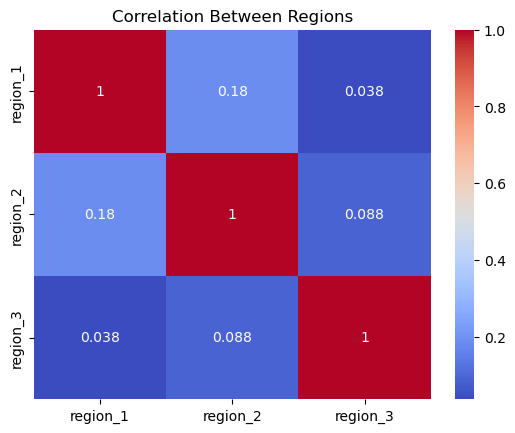

In [18]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Between Regions")
plt.show()

The correlation heatmap shows that the relationships between the three regions are weak, as all correlation values are close to zero. This indicates that the values in one region do not strongly influence or predict the values in the others.

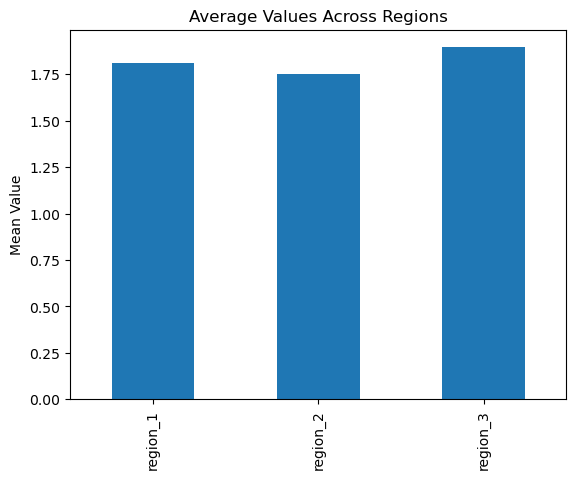

In [20]:
df.mean().plot(kind='bar')

plt.title("Average Values Across Regions")
plt.ylabel("Mean Value")
plt.show()

The bar chart shows the average values across the three regions, indicating that region 3 has the highest mean value, followed by region 1, while region 2 has the lowest.

In [22]:
outliers = {}

for col in ['region_1', 'region_2', 'region_3']:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers[col] = df[(df[col] < lower) | (df[col] > upper)]

# Print number of outliers
for col in outliers:
    print(col, "Outliers:", len(outliers[col]))

region_1 Outliers: 2
region_2 Outliers: 0
region_3 Outliers: 0


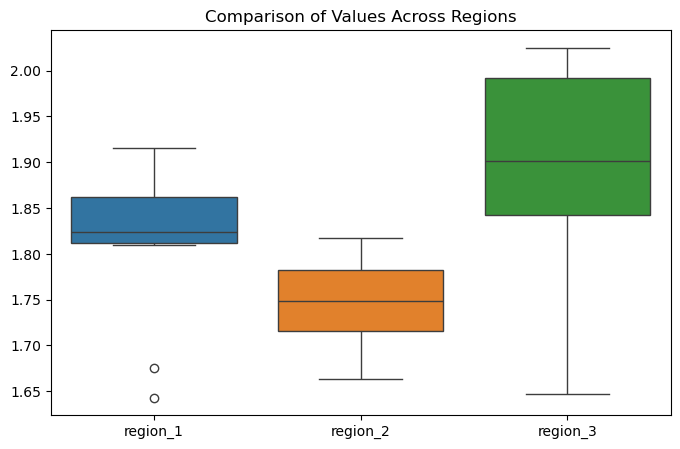

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df)

plt.title("Comparison of Values Across Regions")
plt.show()

The boxplot shows clear differences in the distribution of values across the three regions. Region 3 has the highest median and the widest spread, indicating greater variability and generally higher values compared to the other regions. Region 2 shows the lowest median with a more compact distribution, while region 1 lies in between but contains a few lower outliers, suggesting occasional deviations from its typical range.

### calculate the sample mean and sample size for each region

In [26]:
for col in df.columns:
    print(col)
    print(f"The mean of {col} is {df[col].mean()}")
    print(f"The sample size of {col} is {df[col].count()}")
    print("\n")

region_1
The mean of region_1 is 1.80954920913898
The sample size of region_1 is 10


region_2
The mean of region_2 is 1.7482126411672734
The sample size of region_2 is 10


region_3
The mean of region_3 is 1.8939513606635228
The sample size of region_3 is 10




### save the sample mean, sample size, true mean and true std into a dictionary

In [57]:
stats_dict = {
    col: {
        "mean": df[col].mean(),
        "size": df[col].count()
    }
    for col in df.columns
}

# Assign true (population) values
stats_dict["region_1"]["mu"] = 1.8      #true mean
stats_dict["region_1"]["sigma"] = 0.1       #true std

stats_dict["region_2"]["mu"] = 1.75
stats_dict["region_2"]["sigma"] = 0.05

stats_dict["region_3"]["mu"] = 1.9
stats_dict["region_3"]["sigma"] = 0.1

# Print result
print(stats_dict)

{'region_1': {'mean': 1.80954920913898, 'size': 10, 'mu': 1.8, 'sigma': 0.1}, 'region_2': {'mean': 1.7482126411672734, 'size': 10, 'mu': 1.75, 'sigma': 0.05}, 'region_3': {'mean': 1.8939513606635228, 'size': 10, 'mu': 1.9, 'sigma': 0.1}}


### calculate the standard error for each region and save it into the dictionary

In [59]:
for key in stats_dict.keys():
    stats_dict[key]["se"]=stats_dict[key]["sigma"]/(stats_dict[key]["size"]**0.5)

print(stats_dict)

{'region_1': {'mean': 1.80954920913898, 'size': 10, 'mu': 1.8, 'sigma': 0.1, 'se': 0.03162277660168379}, 'region_2': {'mean': 1.7482126411672734, 'size': 10, 'mu': 1.75, 'sigma': 0.05, 'se': 0.015811388300841896}, 'region_3': {'mean': 1.8939513606635228, 'size': 10, 'mu': 1.9, 'sigma': 0.1, 'se': 0.03162277660168379}}


### Z-test for 1 tailed, right

In [70]:
from scipy.stats import norm

stats=stats_dict["region_3"]
mu=stats["mu"] #population mean(Null)
xbar=stats["mean"] #Sample mean
se=stats["se"] #standard error
alpha=0.01 #significance value

#formula
z= (xbar - mu)/se

p_value=1.0 - norm.cdf(z)  #one tailed and right,cumulative distribution function

print("Region 3")
print(f"There is a {100.*p_value}% chance of the observed mean being different to {xbar} given the underlying mean is {mu}")

if p_value<alpha:
    print(f"Reject the null hypothesis at the {100.*alpha:.1f}% dignifance level")
else:
    print(f"There isn't sufficient evidence to reject the null hypothesis at the {100.*alpha:.1f}% significance level")

Region 3
There is a 57.58448368044685% chance of the observed mean being different to 1.8939513606635228 given the underlying mean is 1.9
There isn't sufficient evidence to reject the null hypothesis at the 1.0% significance level


### Z-test for 2 tailed

In [75]:
from scipy.stats import norm

stats=stats_dict["region_1"]
mu=stats["mu"] #population mean(Null)
xbar=stats["mean"] #Sample mean
se=stats["se"] #standard error
alpha=0.01 #significance value

#formula
z= (xbar - mu)/se

if z>0:
    p_value=2.0*(1.0 - norm.cdf(z))  #cumulative distribution function
else:
    p_value=2.0*norm.cdf(z)

print("Region 1")
print(f"There is a {100.*p_value}% chance of the observed mean being different to {xbar} given the underlying mean is {mu}")

if p_value<alpha:
    print(f"Reject the null hypothesis at the {100.*alpha:.1f}% dignifance level")
else:
    print(f"There isn't sufficient evidence to reject the null hypothesis at the {100.*alpha:.1f}% significance level")

Region 1
There is a 76.26730211598354% chance of the observed mean being different to 1.80954920913898 given the underlying mean is 1.8
There isn't sufficient evidence to reject the null hypothesis at the 1.0% significance level


### 1 tailed left

In [80]:
from scipy.stats import norm

stats=stats_dict["region_3"]
mu=stats["mu"] #population mean(Null)
xbar=stats["mean"] #Sample mean
se=stats["se"] #standard error
alpha=0.01 #significance value

#formula
z= (xbar - mu)/se

p_value=norm.cdf(z)  #one tailed and left,cumulative distribution function

print("Region 3")
print(f"There is a {100.*p_value}% chance of the observed mean being different to {xbar} given the underlying mean is {mu}")

if p_value<alpha:
    print(f"Reject the null hypothesis at the {100.*alpha:.1f}% dignifance level")
else:
    print(f"There isn't sufficient evidence to reject the null hypothesis at the {100.*alpha:.1f}% significance level")

Region 3
There is a 42.41551631955315% chance of the observed mean being different to 1.8939513606635228 given the underlying mean is 1.9
There isn't sufficient evidence to reject the null hypothesis at the 1.0% significance level


### chi square

In [91]:
from scipy.stats import chi2

stats = stats_dict["region_3"]

mu = stats["mu"]        # expected (population mean)
xbar = stats["mean"]   # observed (sample mean)
se = stats["se"]       # standard error
alpha = 0.01           # significance level

# Chi-square formula
chi_stat = ((xbar - mu)**2) / (se**2)

# degrees of freedom
df = 1

# p-value (right-tailed)
p_value = 1.0 - chi2.cdf(chi_stat,df)

print("Region 3")
print(f"Chi-square statistic: {chi_stat}")
print(f"There is a {100.*p_value}% chance of the observed mean being different from {mu}")

if p_value < alpha:
    print(f"Reject the null hypothesis at the {100.*alpha:.1f}% significance level")
else:
    print(f"There isn't sufficient evidence to reject the null hypothesis at the {100.*alpha:.1f}% significance level")

Region 3
Chi-square statistic: 0.0365860378227787
There is a 84.8310326391063% chance of the observed mean being different from 1.9
There isn't sufficient evidence to reject the null hypothesis at the 1.0% significance level
